# Kuzmin LOOCV HAVEN Fine Tuning Analysis

In [1]:
# from src.evaluation.binary_class_evaluation import 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score, precision_recall_curve
import sys, os, subprocess


In [2]:
kuzmin = pd.read_csv("../../../../input/data/kuzmin/kuzmin_no_gaps.csv")
witheld = kuzmin[kuzmin['virus_species'] != "Severe_acute_respiratory_syndrome_related_coronavirus"]

In [4]:
kuzmin = kuzmin.drop('Unnamed: 0', axis=1)
kuzmin.to_csv("../../../../input/data/kuzmin/kuzmin_no_gaps.csv")

In [5]:
human_virus_species_set = {
    "Human_coronavirus_NL63",
    "Betacoronavirus_1",
    "Human_coronavirus_HKU1",
    "Severe_acute_respiratory_syndrome_related_coronavirus",
    "SARS_CoV_2",
    "Human_coronavirus_229E",
    "Middle_East_respiratory_syndrome_coronavirus",
}

virus_list = witheld['virus_species'].unique()

def is_human_virus(virus_species):
    if virus_species in human_virus_species_set:
        return 1
    else: 
        return 0
    
def get_virus_species(itr):
    return virus_list[itr]

def merge_cols(row):
    positive_label = row[2]
    one = row[6]
    if not pd.isna(positive_label):
        return positive_label
    else:
        return one
    
    

In [6]:
results = pd.read_csv("kuzmin_hybrid_attention_LOOCV_2l_d1024_lr3e-4_output.csv")
results['virus_species'] = results['itr'].apply(get_virus_species)
results['target'] = results['virus_species'].apply(is_human_virus)
results['target_pred'] = results.apply(merge_cols, axis=1)

In [7]:
fpr, tpr, _ = roc_curve(results['target'], results['target_pred'])
auc = roc_auc_score(results['target'], results['target_pred'])

In [8]:
# Get average pred by species 
results_by_species = results.groupby('virus_species').agg("mean").reset_index()
# display(results_by_species)
fpr_species, tpr_species, _ = roc_curve(results_by_species['target'], results_by_species['target_pred'])
auc_species = roc_auc_score(results_by_species['target'], results_by_species['target_pred'])

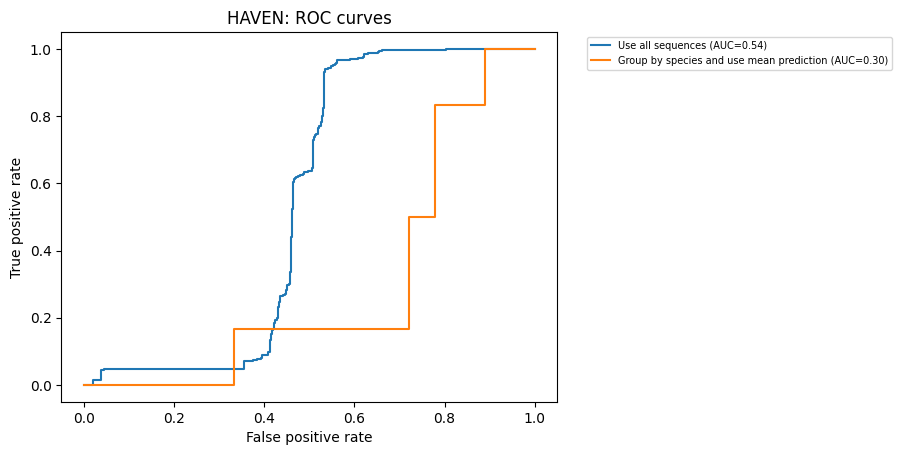

In [9]:
plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))
plt.step(fpr_species,tpr_species,where="post",label="Group by species and use mean prediction (AUC=%.2f)" % (auc_species,),)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("HAVEN: ROC curves")
plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
plt.savefig('model_eval_ROC.jpg', bbox_inches='tight')

plt.show()

# Replicates of HAVEN Fine Tuning

In [ ]:
staging_folder = "aranastasi@ap2001.chtc.wisc.edu:/staging/aranastasi/HAVEN/outputs/LOOCV_reps"

for rep in range(0, 4):
    # Download and untar fine tuning models 

    subprocess.run(["mkdir", "-p", f"rep{rep}"])
    
    subprocess.run(
        [
            "scp",
            f"{staging_folder}/kuzmin_LOOCV_fine_tuning_rep{rep}.tar.gz" f"rep{rep}",
        ]
    ) 

    # print(f"Command: gtar -xzf {local_bagged_CV_folder}/{subfolder_name}.tar.gz -C {local_bagged_CV_folder}/")

    subprocess.run(
        [
            "gtar",
            "-xzf",
            f"rep{rep}/kuzmin_LOOCV_fine_tuning_rep{rep}.tar.gz",
            "-C",
            f"outputs/",
        ]
    )

usage: scp [-346ABCOpqRrsTv] [-c cipher] [-D sftp_server_path] [-F ssh_config]
           [-i identity_file] [-J destination] [-l limit] [-o ssh_option]
           [-P port] [-S program] [-X sftp_option] source ... target
tar (child): kuzmin_LOOCV_fine_tuning_rep0.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
gtar: Child returned status 2
gtar: Error is not recoverable: exiting now
usage: scp [-346ABCOpqRrsTv] [-c cipher] [-D sftp_server_path] [-F ssh_config]
           [-i identity_file] [-J destination] [-l limit] [-o ssh_option]
           [-P port] [-S program] [-X sftp_option] source ... target
tar (child): kuzmin_LOOCV_fine_tuning_rep1.tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
gtar: Child returned status 2
gtar: Error is not recoverable: exiting now
usage: scp [-346ABCOpqRrsTv] [-c cipher] [-D sftp_server_path] [-F ssh_config]
           [-i identity_file] [-J destination] 

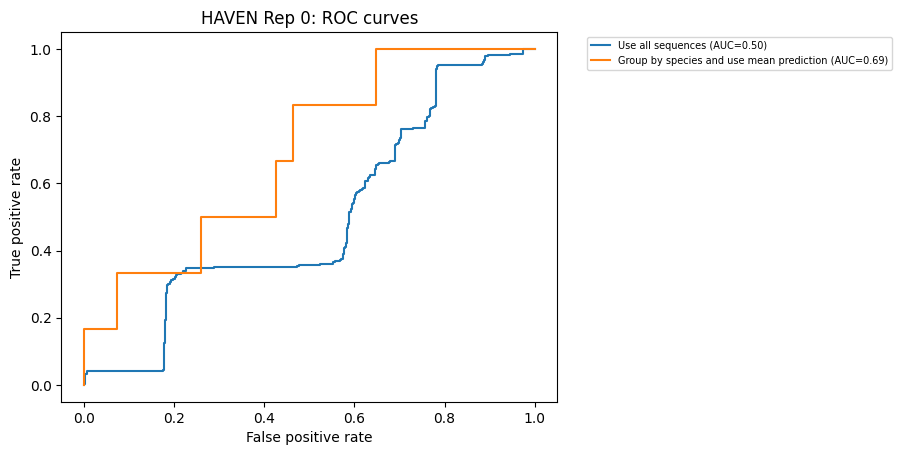

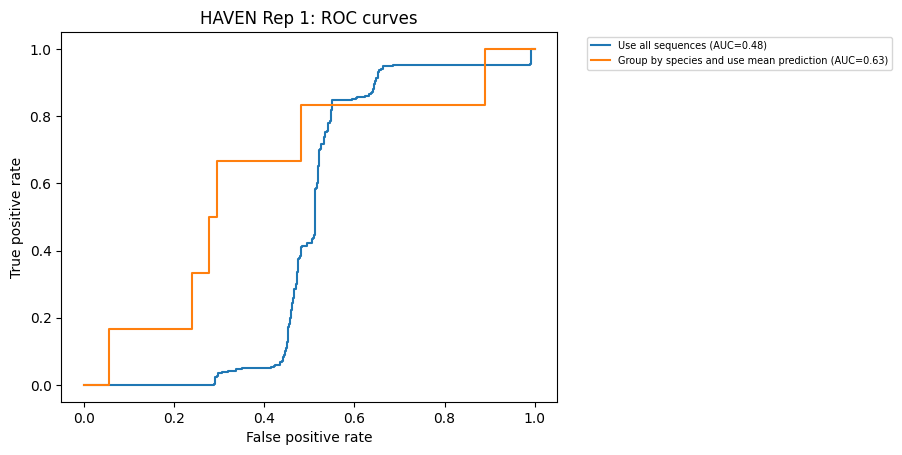

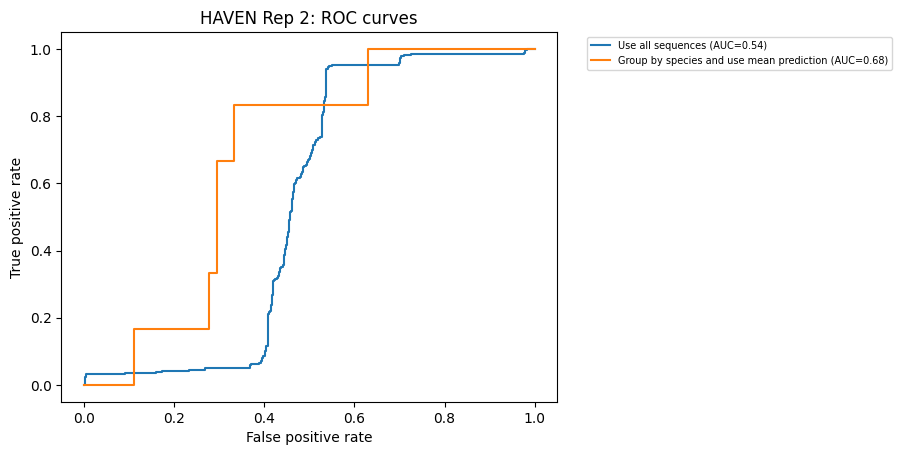

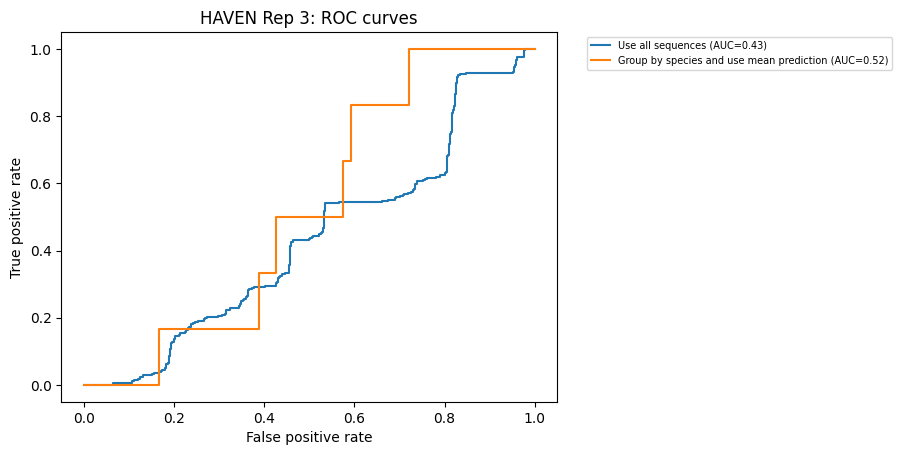

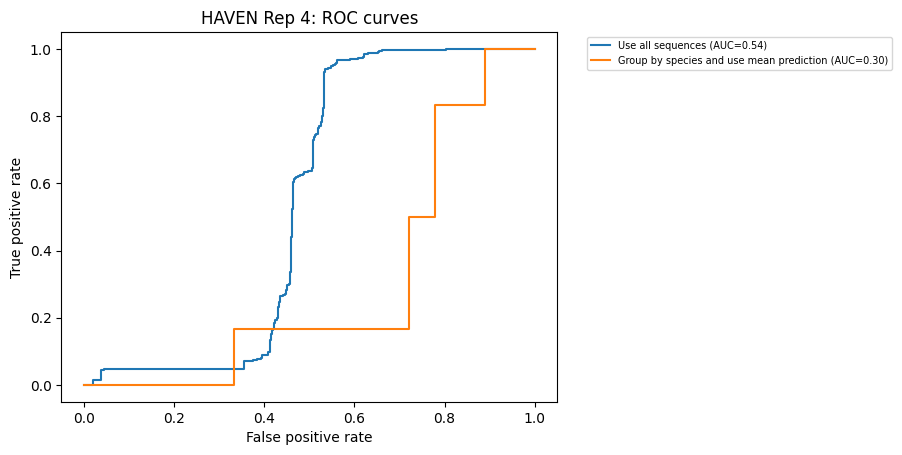

In [22]:
for rep in range(0, 5):
    results = pd.read_csv(f"rep{rep}/kuzmin_hybrid_attention_LOOCV_2l_d1024_lr3e-4_output.csv")
    results['virus_species'] = results['itr'].apply(get_virus_species)
    results['target'] = results['virus_species'].apply(is_human_virus)
    results['target_pred'] = results.apply(merge_cols, axis=1)

    # display(results)
    
    fpr, tpr, _ = roc_curve(results['target'], results['target_pred'])
    auc = roc_auc_score(results['target'], results['target_pred'])

    # Get average pred by species 
    results_by_species = results.groupby('virus_species').agg("mean").reset_index()
    # display(results_by_species)
    fpr_species, tpr_species, _ = roc_curve(results_by_species['target'], results_by_species['target_pred'])
    auc_species = roc_auc_score(results_by_species['target'], results_by_species['target_pred'])

    plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))
    plt.step(fpr_species,tpr_species,where="post",label="Group by species and use mean prediction (AUC=%.2f)" % (auc_species,),)

    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"HAVEN Rep {rep}: ROC curves")
    plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
    plt.savefig('model_eval_ROC.jpg', bbox_inches='tight')

    plt.show()

    if rep != 4:
        plt.cla()

# Results of Test Run

This run had an 80/10/10 split of training, validation, and test without leaving anything out. 

In [25]:
kuzmin_test = pd.read_csv("kuzmin_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
kuzmin_test.sample(10)

,Unnamed: 0,negative_label,positive_label,y_true,itr
303,55,0.832953,0.167047,negative_label,2
199,75,0.924910,0.075090,negative_label,1
161,37,0.037105,0.962895,positive_label,1
474,102,0.044303,0.955697,positive_label,3
361,113,0.013726,0.986274,positive_label,2
47,47,0.027262,0.972738,positive_label,0
272,24,0.030027,0.969973,positive_label,2
46,46,0.020490,0.979510,positive_label,0
100,100,0.723062,0.276938,negative_label,0
581,85,0.045699,0.954301,positive_label,4


In [26]:
def transform_target(y_true):
    if y_true == "positive_label":
        return 1
    else: return 0

kuzmin_test['target'] = kuzmin_test['y_true'].apply(transform_target)
kuzmin_test['positive_label']

0      0.060543
1      0.055943
2      0.977329
3      0.039984
4      0.023906
         ...   
615    0.949643
616    0.051895
617    0.027863
618    0.936923
619    0.950970
Name: positive_label, Length: 620, dtype: float64

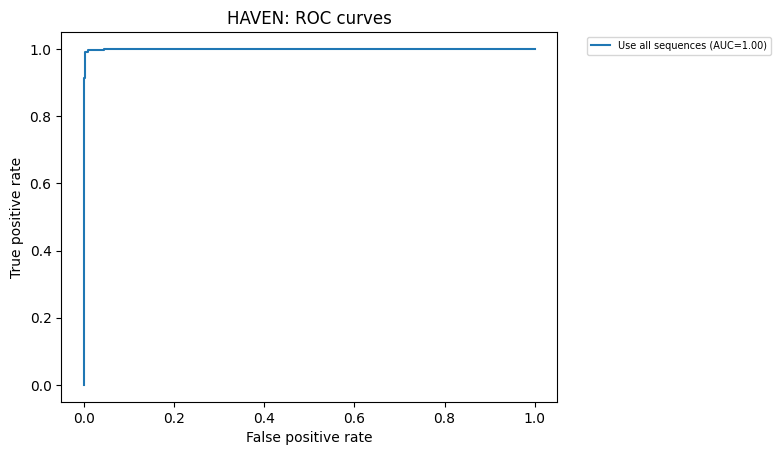

In [28]:

fpr, tpr, _ = roc_curve(kuzmin_test['target'].values, kuzmin_test['positive_label'].values)
auc = roc_auc_score(kuzmin_test['target'].values, kuzmin_test['positive_label'].values)

plt.step(fpr, tpr, where="post", label="Use all sequences (AUC=%.2f)" % (auc,))

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("HAVEN: ROC curves")
plt.legend(loc="upper left", fontsize=7, bbox_to_anchor=(1.05, 1))
plt.savefig('model_eval_ROC_test.jpg', bbox_inches='tight')

plt.show()